# Notebook 03 — Operações com NumPy e Camadas Neurais

## 🎯 Objetivos

Ao final deste notebook, você será capaz de:

- realizar soma, subtração e multiplicações entre arrays;
- diferenciar `*`, `@` e `np.dot`;
- calcular a saída de um ou vários neurônios;
- interpretar a fórmula matricial `Y = XW + b`.

> **Como estudar:** execute as células na ordem. Leia a explicação antes de cada bloco e compare os resultados obtidos com a interpretação apresentada.


## 1. Criando duas matrizes

As matrizes `A` e `B` possuem shape `(2, 2)`. Como têm o mesmo formato, podemos somá-las, subtraí-las e multiplicá-las elemento a elemento.


In [1]:
import numpy as np

A = np.array([
    [1, 2],
    [3, 4]
])

B = np.array([
    [5, 6],
    [7, 8]
])

### Soma elemento a elemento

Cada posição de `A` é somada à posição correspondente de `B`. Os shapes precisam ser compatíveis.


In [2]:
print (A + B)

[[ 6  8]
 [10 12]]


### Subtração elemento a elemento

A operação segue a mesma lógica da soma, mas calcula `A - B` posição por posição.


In [3]:
print (A - B)

[[-4 -4]
 [-4 -4]]


### Multiplicação matricial com `@`

Na multiplicação matricial, combinamos linhas da primeira matriz com colunas da segunda. Esta é a operação central usada para combinar entradas e pesos em uma camada neural.


In [4]:
print (A @ B)

[[19 22]
 [43 50]]


### Multiplicação elemento a elemento com `*`

Aqui não ocorre produto matricial. Cada elemento é multiplicado apenas pelo elemento da mesma posição. Portanto, `A * B` e `A @ B` produzem resultados diferentes.


In [5]:
print (A * B)

[[ 5 12]
 [21 32]]


## 2. Um neurônio artificial

`entrada` contém duas características, `pesos` contém um peso para cada característica e `bias` desloca o resultado. O neurônio calcula o produto escalar e soma o bias.


In [6]:
import numpy as np

entrada = np.array([2, 3])

pesos = np.array([0.5, 0.8])

bias = 1

### Produto escalar com `np.dot`

`np.dot(entrada, pesos)` calcula `2×0.5 + 3×0.8`. Em seguida, adicionamos o bias. A saída é um único número porque há um único neurônio.


In [7]:
resultado = np.dot(entrada, pesos) + bias

print(resultado)

4.4


### A mesma operação com `@`

Para dois vetores unidimensionais, `entrada @ pesos` também calcula o produto escalar. O resultado deve ser igual ao da célula anterior.


In [8]:
resultado = entrada @ pesos + bias

print(resultado)

4.4


utilizando 3 neurônios simultaneamente:

## 3. Três neurônios simultaneamente

A matriz de pesos possui duas linhas e três colunas: duas entradas conectadas a três neurônios. Cada coluna reúne os pesos de um neurônio. O vetor `bias` possui um valor para cada saída.


In [9]:
entrada = np.array([2, 3])

pesos = np.array([
    [0.5, 0.8, 0.2],
    [0.3, 0.7, 0.9]
])

bias = np.array([1, 2, 3])

### Conferindo os shapes

Antes da multiplicação, verifique:

- entrada: `(2,)`;
- pesos: `(2, 3)`;
- bias: `(3,)`.

O eixo interno de tamanho 2 é compatível, e a saída terá tamanho 3.


In [10]:
print("Entrada:", entrada.shape)
print("Pesos:", pesos.shape)
print("Bias:", bias.shape)

Entrada: (2,)
Pesos: (2, 3)
Bias: (3,)


### Calculando as três saídas

A expressão `entrada @ pesos + bias` executa os três neurônios de uma vez. O broadcasting do NumPy adiciona cada bias à saída correspondente.


In [11]:
saida = entrada @ pesos + bias

print(saida)

[2.9 5.7 6.1]


O fluxo é:

 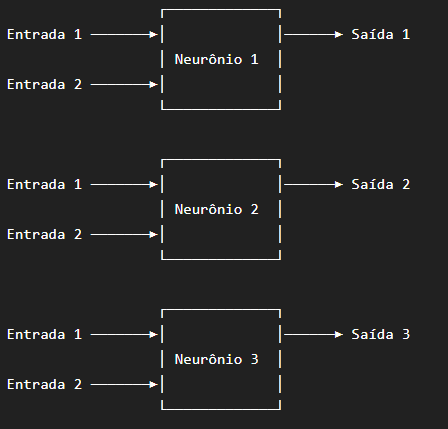


mais compacto:

      2 entradas
          │
          ▼
    ┌─────────────┐
    │             │
    │  3 neurônios│
    │             │
    └─────────────┘
          │
          ▼
      3 saídas

### Representação compacta da camada

```text
Input
  │
  │ 2 características
  ▼
Dense Layer
  │
  │ 3 neurônios
  ▼
Output
```

Matematicamente:

\[
Y = XW + b
\]

- `X`: entradas;
- `W`: matriz de pesos;
- `b`: vetor de biases;
- `Y`: saída da camada.


## 4. Processando um lote de exemplos

Agora `entradas` contém quatro linhas. Cada linha é um exemplo com duas características. Em Deep Learning, esse conjunto de exemplos processado em conjunto é chamado de **batch** ou lote.


In [12]:
entradas = np.array([
    [2, 3],
    [4, 5],
    [6, 7],
    [8, 9]
])

print("Shape das entradas:", entradas.shape)

Shape das entradas: (4, 2)


### Saída do lote

A multiplicação `(4, 2) @ (2, 3)` produz `(4, 3)`: quatro exemplos e três saídas para cada exemplo. O bias `(3,)` é adicionado a todas as linhas.


In [13]:
saida = entradas @ pesos + bias

print(saida)
print("Shape da saída:", saida.shape)

[[ 2.9  5.7  6.1]
 [ 4.5  8.7  8.3]
 [ 6.1 11.7 10.5]
 [ 7.7 14.7 12.7]]
Shape da saída: (4, 3)


4 entradas
    ↓
2 características
    ↓
3 neurônios
    ↓
3 saídas

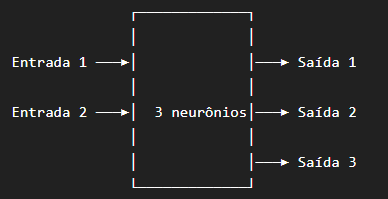

## 🧠 Conclusão

Passamos de operações básicas entre matrizes para o cálculo vetorizado de uma camada neural. A vetorização permite processar vários neurônios e vários exemplos sem escrever loops individuais.

### Erro comum

Confundir `*` com `@` pode alterar completamente o cálculo. Sempre confira os shapes antes de multiplicar matrizes.

### Exercícios

1. Adicione um quarto neurônio, ajustando pesos e bias.
2. Crie cinco exemplos com duas características e confira o shape da saída.
3. Calcule manualmente a primeira saída do primeiro exemplo e compare com o NumPy.

### Próximo notebook

No Notebook 04, aplicaremos funções de ativação às saídas lineares da camada.
